# 05 时频分析：STFT 与 CWT

**本节目标**

1. 用 STFT 观察外圈故障信号在共振频带（4 kHz 附近）的周期性亮纹——每次冲击一条；
2. 用复 Morlet CWT 重做一次，对比两者的时频分辨率差异；
3. 理解不确定性原理带来的时频分辨率折中。

**原理**（详见 [docs/06 时频分析](../docs/06_time_frequency.md)）

冲击是"持续时间短、频带宽"的事件，单看波形或频谱都无法同时定位它的时间和频率。
时频分析把信号展开到时间-频率平面：

- **STFT**：固定窗长做分段 FFT，时频分辨率全频段一致，
  受不确定性原理 $\Delta t \cdot \Delta f \geq 1/(4\pi)$ 限制；
- **CWT**：用尺度可伸缩的小波（此处为复 Morlet），高频处时间短、低频处频率准，
  更适合定位瞬态冲击。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from bearing_fault import BearingSimulator, cwt_spectrogram, stft_spectrogram
from bearing_fault.plotting import plot_timefreq

FS, RPM, DURATION, SEED = 12000, 1797, 3.0, 42
x = BearingSimulator(fs=FS, duration=DURATION, rpm=RPM, seed=SEED).signal("outer", snr_db=-6.0)
BPFO = 107.36  # 外圈特征频率，冲击间隔 ≈ 9.3 ms

## STFT：共振频带的周期性亮纹

窗长取 `nperseg=256`（约 21 ms），频率分辨率约 47 Hz。
每次冲击激发 4 kHz 共振，在时频图上留下一条竖直亮纹；
亮纹的时间间隔 ≈ 1/BPFO ≈ 9.3 ms。把时间轴放大到 0–0.5 s 观察。

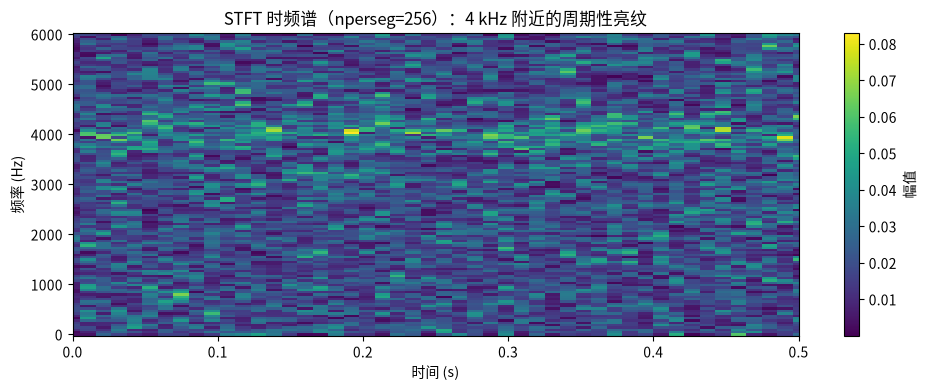

In [2]:
t_s, f_s, z_s = stft_spectrogram(x, FS, nperseg=256)
fig, ax = plot_timefreq(t_s, f_s, z_s, title="STFT 时频谱（nperseg=256）：4 kHz 附近的周期性亮纹")
ax.set_xlim(0, 0.5)
plt.show()

## 窗长的影响：时间与频率不可兼得

把窗长加大到 1024（约 85 ms）：频率轴更精细，但冲击亮纹在时间上被拉宽、彼此粘连。
这就是不确定性原理的直观体现。

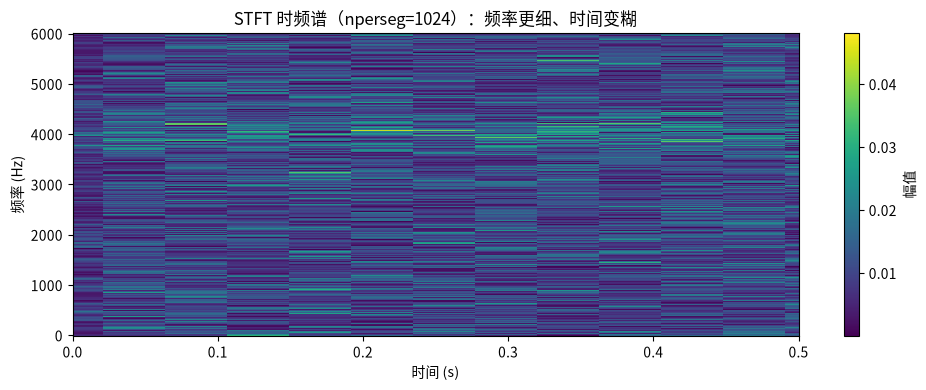

In [3]:
t_s2, f_s2, z_s2 = stft_spectrogram(x, FS, nperseg=1024)
fig, ax = plot_timefreq(t_s2, f_s2, z_s2, title="STFT 时频谱（nperseg=1024）：频率更细、时间变糊")
ax.set_xlim(0, 0.5)
plt.show()

## CWT：高频处更好的时间分辨率

复 Morlet 小波在高频处自动变"窄"，冲击定位更锐利。
频率刻度取 500–5500 Hz 的 40 个对数间隔点（对数刻度是小波分析的惯例）。

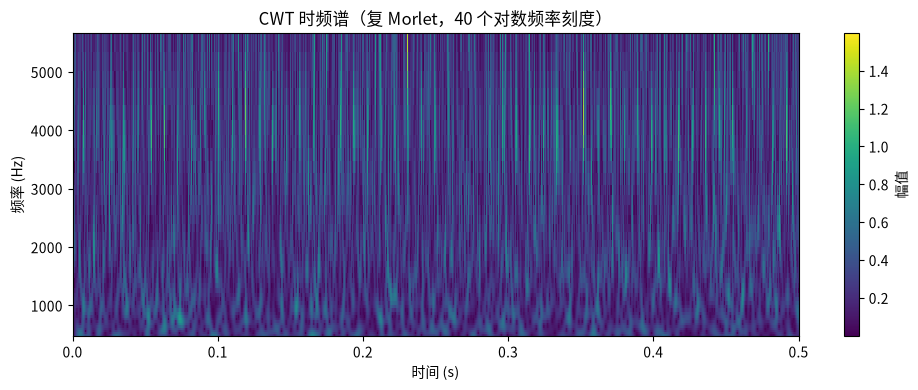

In [4]:
freqs_c = np.geomspace(500, 5500, 40)
t_c, f_c, z_c = cwt_spectrogram(x, FS, freqs_c)
fig, ax = plot_timefreq(t_c, f_c, z_c, title="CWT 时频谱（复 Morlet，40 个对数频率刻度）")
ax.set_xlim(0, 0.5)
plt.show()

**对比与讨论**

| | STFT | CWT |
|---|---|---|
| 分辨率结构 | 固定窗长，全频段一致 | 高频时间短、低频频率准 |
| 冲击定位 | 高频处时间分辨率不足，亮纹偏宽 | 高频处亮纹锐利，冲击间隔清晰 |
| 适用场景 | 平稳/准平稳信号、快速筛查 | 瞬态冲击、非平稳信号 |

两种方法都能直观展示"4 kHz 共振带 + 周期性冲击"这一故障特征，
但在定量诊断中，包络谱（第 03 节）仍是更直接的手段——时频分析更适合
变工况、非平稳信号的可视化与机理分析。

→ 下一节：[06 完整诊断流程](06_full_pipeline.ipynb)